# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel File

In [6]:
df = pd.read_excel("web_traffic.xlsx")

# View Dataset

In [3]:
df.head()

,Date,Page,Traffic_Source,Sessions,Users,Bounce_Rate(%),Avg_Session_Duration(sec),Pages_per_Session,Conversions,Goal_Completions,Revenue($)
0,2026-01-01,Home,Organic,1250,980,38,245,4.8,72,95,3600
1,2026-01-01,Products,Paid,980,790,45,210,3.9,65,80,4200
2,2026-01-01,Blog,Organic,720,650,58,180,2.8,18,25,700
3,2026-01-01,Contact,Referral,260,210,34,155,2.4,22,28,1000
4,2026-01-01,Pricing,Direct,540,470,29,280,5.2,48,60,2900


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       35 non-null     datetime64[ns]
 1   Page                       35 non-null     object        
 2   Traffic_Source             35 non-null     object        
 3   Sessions                   35 non-null     int64         
 4   Users                      35 non-null     int64         
 5   Bounce_Rate(%)             35 non-null     int64         
 6   Avg_Session_Duration(sec)  35 non-null     int64         
 7   Pages_per_Session          35 non-null     float64       
 8   Conversions                35 non-null     int64         
 9   Goal_Completions           35 non-null     int64         
 10  Revenue($)                 35 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(7), object(2)
memory usage: 3.1+ 

In [8]:
df.describe()

,Date,Sessions,Users,Bounce_Rate(%),Avg_Session_Duration(sec),Pages_per_Session,Conversions,Goal_Completions,Revenue($)
count,35,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,2026-01-04 00:00:00,795.428571,659.142857,36.600000,239.800000,4.380000,58.371429,69.828571,3207.142857
min,2026-01-01 00:00:00,260.000000,210.000000,17.000000,155.000000,2.400000,15.000000,20.000000,620.000000
25%,2026-01-02 00:00:00,455.000000,400.000000,30.500000,195.000000,3.300000,24.500000,30.000000,1050.000000
50%,2026-01-04 00:00:00,710.000000,620.000000,35.000000,235.000000,4.600000,65.000000,80.000000,3500.000000
75%,2026-01-06 00:00:00,1140.000000,915.000000,41.500000,280.000000,5.250000,79.500000,97.000000,4575.000000
max,2026-01-07 00:00:00,1500.000000,1200.000000,58.000000,335.000000,6.300000,110.000000,115.000000,6400.000000
std,NaN,377.393092,289.922621,11.170339,53.445299,1.188128,29.719360,33.241085,1883.583211


# Check Missing Values

In [9]:
df.isnull().sum()

Date                         0
Page                         0
Traffic_Source               0
Sessions                     0
Users                        0
Bounce_Rate(%)               0
Avg_Session_Duration(sec)    0
Pages_per_Session            0
Conversions                  0
Goal_Completions             0
Revenue($)                   0
dtype: int64

In [10]:
df.fillna(0, inplace=True)

# Check Duplicate Records

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

# Convert Date Column

In [13]:
df["Date"] = pd.to_datetime(df["Date"])

# Check Data Types

In [14]:
df["Conversion_Rate (%)"] = (df["Conversions"] / df["Sessions"]) * 100

In [15]:
df["Goal_Completion_Rate (%)"] = (df["Goal_Completions"] / df["Sessions"]) * 100

# Clean Dataset Completed

In [16]:
df.head()

,Date,Page,Traffic_Source,Sessions,Users,Bounce_Rate(%),Avg_Session_Duration(sec),Pages_per_Session,Conversions,Goal_Completions,Revenue($),Conversion_Rate (%),Goal_Completion_Rate (%)
0,2026-01-01,Home,Organic,1250,980,38,245,4.8,72,95,3600,5.760000,7.600000
1,2026-01-01,Products,Paid,980,790,45,210,3.9,65,80,4200,6.632653,8.163265
2,2026-01-01,Blog,Organic,720,650,58,180,2.8,18,25,700,2.500000,3.472222
3,2026-01-01,Contact,Referral,260,210,34,155,2.4,22,28,1000,8.461538,10.769231
4,2026-01-01,Pricing,Direct,540,470,29,280,5.2,48,60,2900,8.888889,11.111111


# GRAPHS

## 1. Traffic Source Distribution

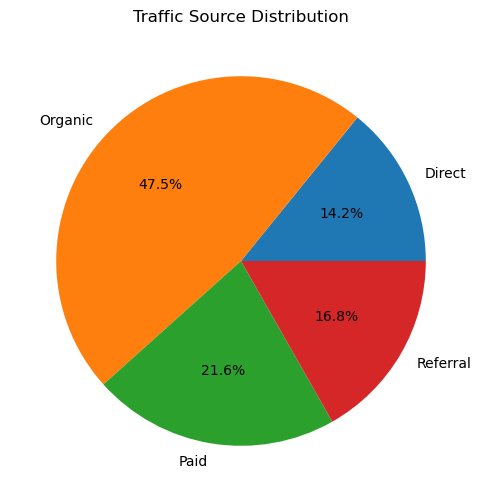

In [17]:
traffic = df.groupby("Traffic_Source")["Sessions"].sum()

plt.figure(figsize=(8,6))
traffic.plot(kind="pie", autopct="%1.1f%%")
plt.title("Traffic Source Distribution")
plt.ylabel("")
plt.show()

## 2. Sessions by Page

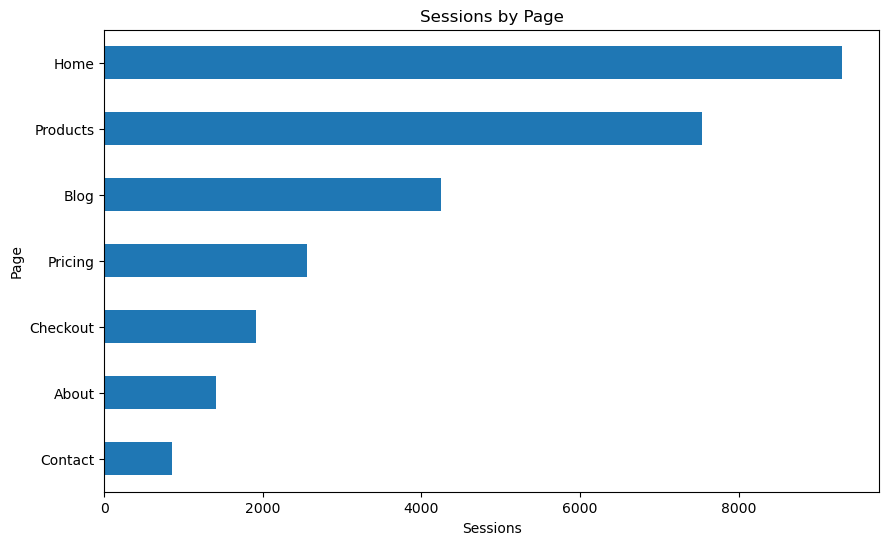

In [18]:
page_sessions = df.groupby("Page")["Sessions"].sum().sort_values()

plt.figure(figsize=(10,6))
page_sessions.plot(kind="barh")
plt.title("Sessions by Page")
plt.xlabel("Sessions")
plt.show()

## 3. Bounce Rate by Page

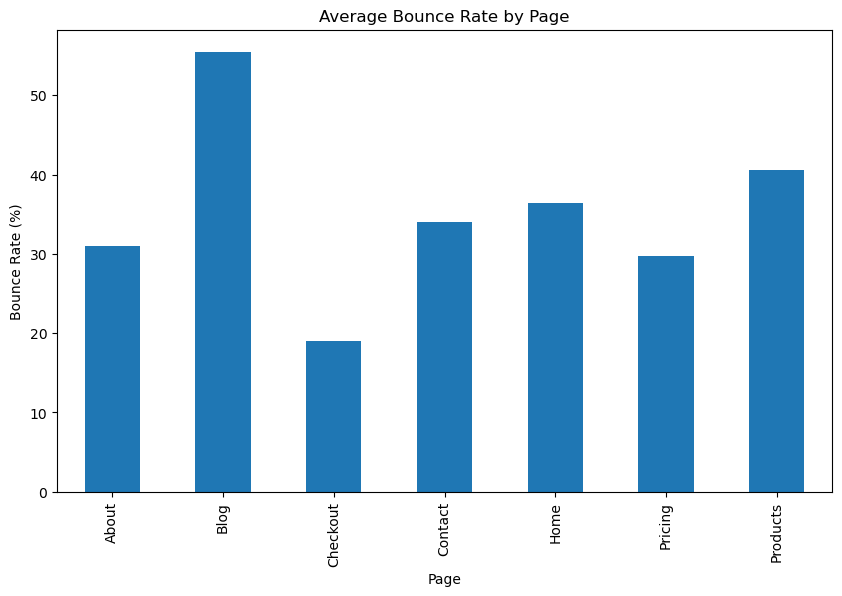

In [19]:
bounce = df.groupby("Page")["Bounce_Rate(%)"].mean()

plt.figure(figsize=(10,6))
bounce.plot(kind="bar")
plt.title("Average Bounce Rate by Page")
plt.ylabel("Bounce Rate (%)")
plt.show()

## 4. User Trend Over Time

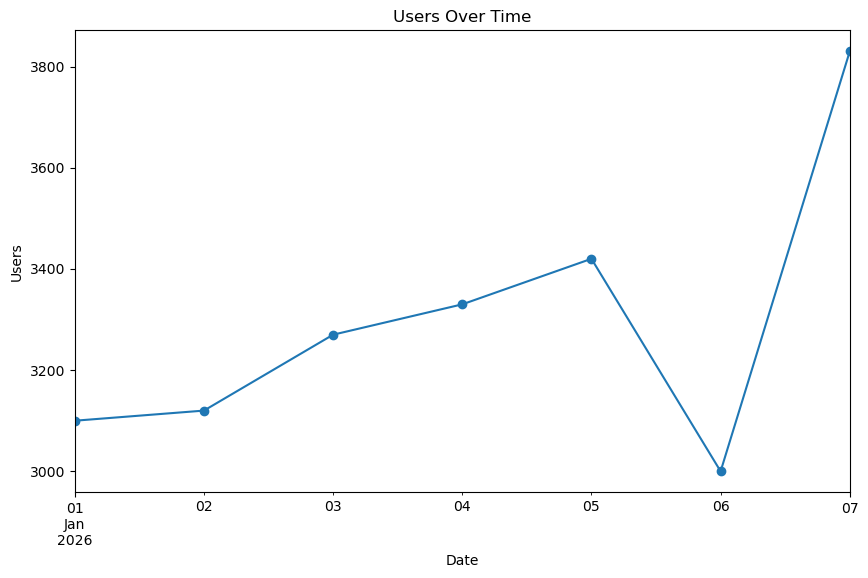

In [20]:
daily_users = df.groupby("Date")["Users"].sum()

plt.figure(figsize=(10,6))
daily_users.plot(marker='o')
plt.title("Users Over Time")
plt.ylabel("Users")
plt.show()

## 5. Sessions Over Time

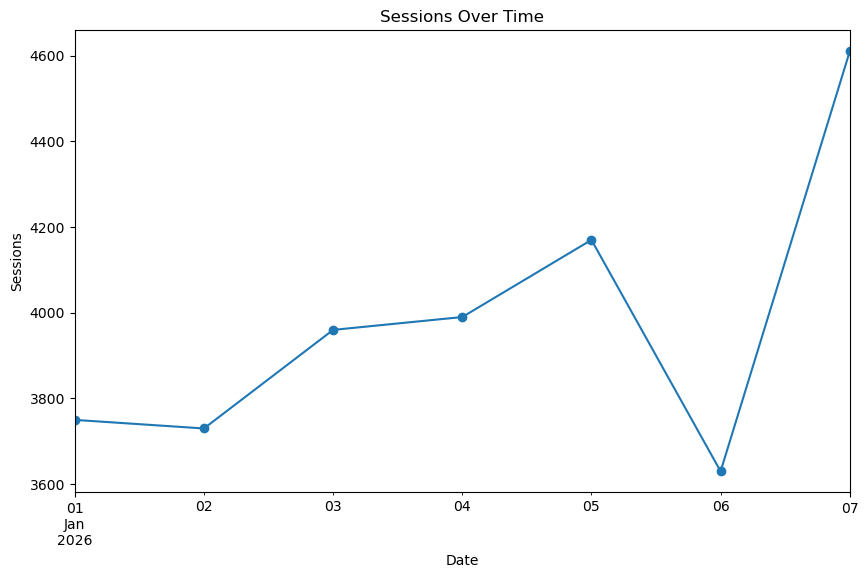

In [21]:
daily_sessions = df.groupby("Date")["Sessions"].sum()

plt.figure(figsize=(10,6))
daily_sessions.plot(marker='o')
plt.title("Sessions Over Time")
plt.ylabel("Sessions")
plt.show()

## 6. Revenue by Traffic Source

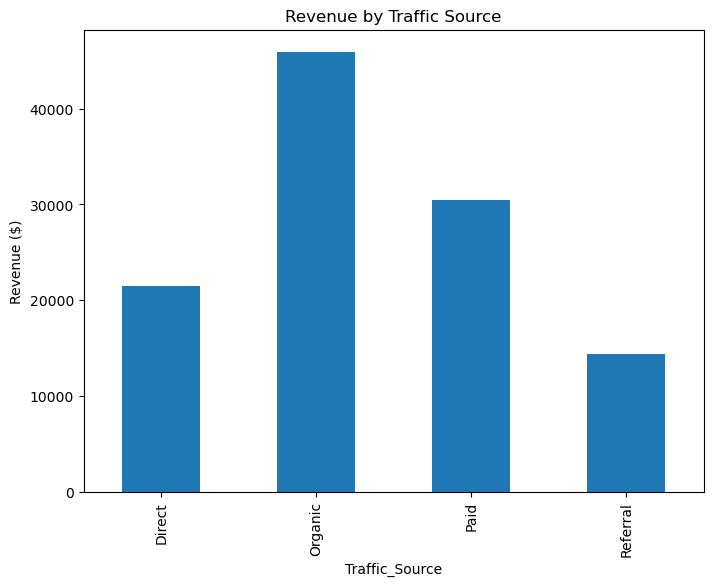

In [22]:
revenue = df.groupby("Traffic_Source")["Revenue($)"].sum()

plt.figure(figsize=(8,6))
revenue.plot(kind="bar")
plt.title("Revenue by Traffic Source")
plt.ylabel("Revenue ($)")
plt.show()

## 7. Conversion Rate by Page

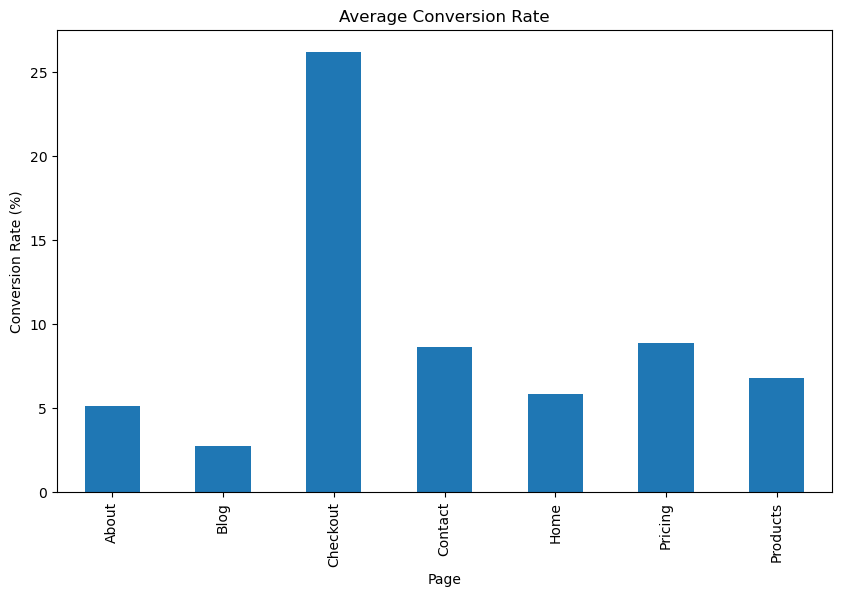

In [23]:
conversion = df.groupby("Page")["Conversion_Rate (%)"].mean()

plt.figure(figsize=(10,6))
conversion.plot(kind="bar")
plt.title("Average Conversion Rate")
plt.ylabel("Conversion Rate (%)")
plt.show()

## 8. Goal Completions by Page

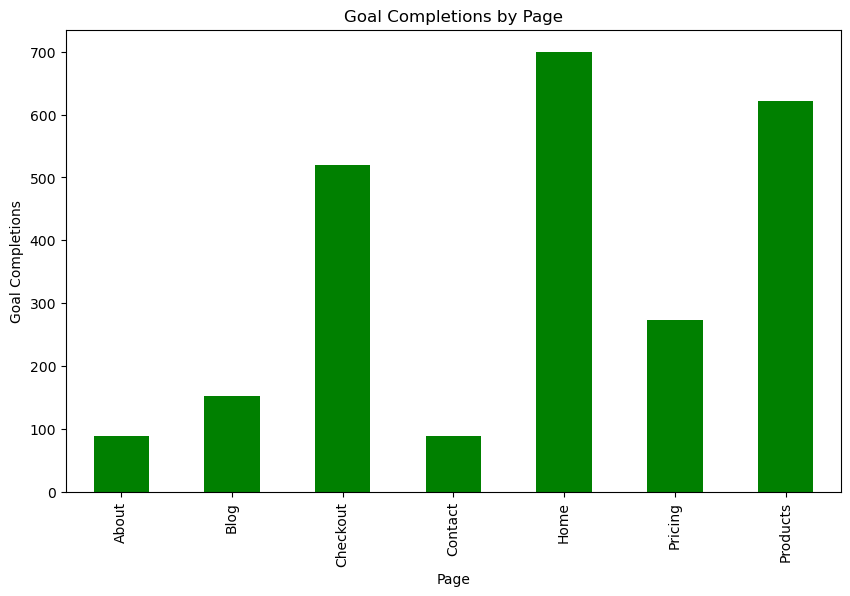

In [24]:
goal = df.groupby("Page")["Goal_Completions"].sum()

plt.figure(figsize=(10,6))
goal.plot(kind="bar", color="green")
plt.title("Goal Completions by Page")
plt.ylabel("Goal Completions")
plt.show()

## 9. Average Session Duration

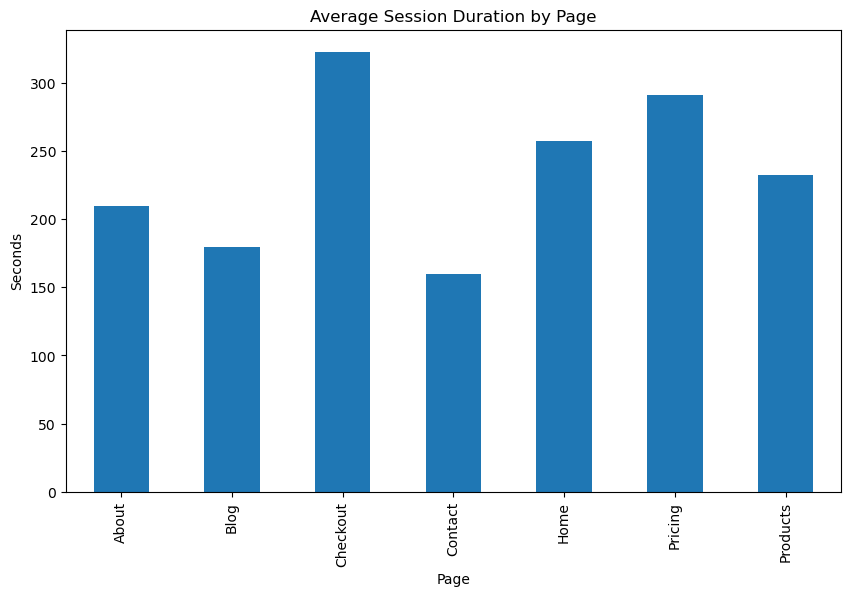

In [25]:
duration = df.groupby("Page")["Avg_Session_Duration(sec)"].mean()

plt.figure(figsize=(10,6))
duration.plot(kind="bar")
plt.title("Average Session Duration by Page")
plt.ylabel("Seconds")
plt.show()

## 10. Pages Per Session

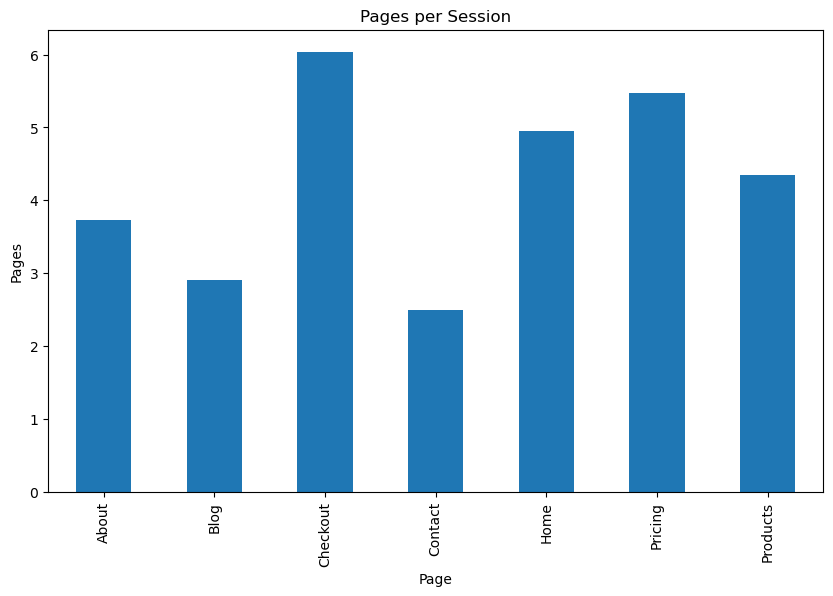

In [26]:
pps = df.groupby("Page")["Pages_per_Session"].mean()

plt.figure(figsize=(10,6))
pps.plot(kind="bar")
plt.title("Pages per Session")
plt.ylabel("Pages")
plt.show()

## 11. Top Performing Pages

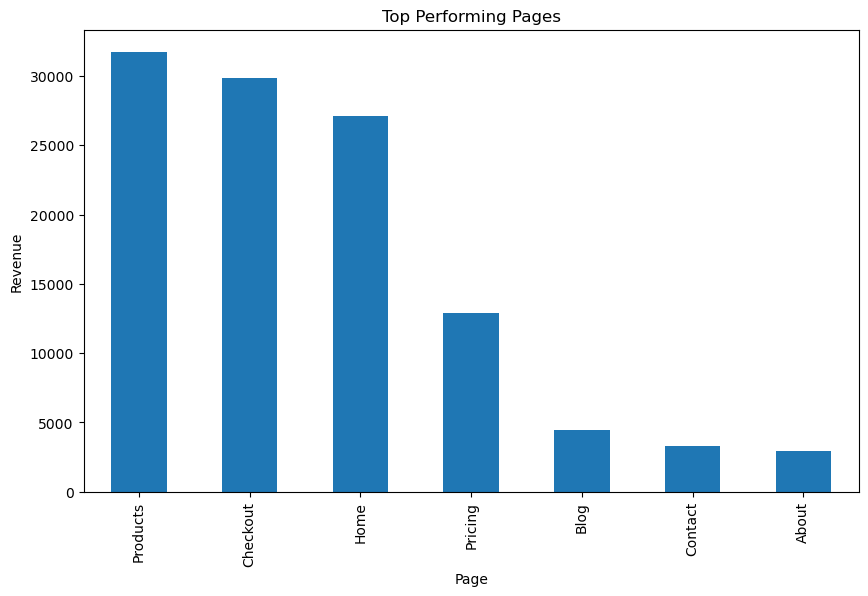

In [27]:
top = df.groupby("Page")["Revenue($)"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
top.plot(kind="bar")
plt.title("Top Performing Pages")
plt.ylabel("Revenue")
plt.show()

## 12. Correlation Heatmap

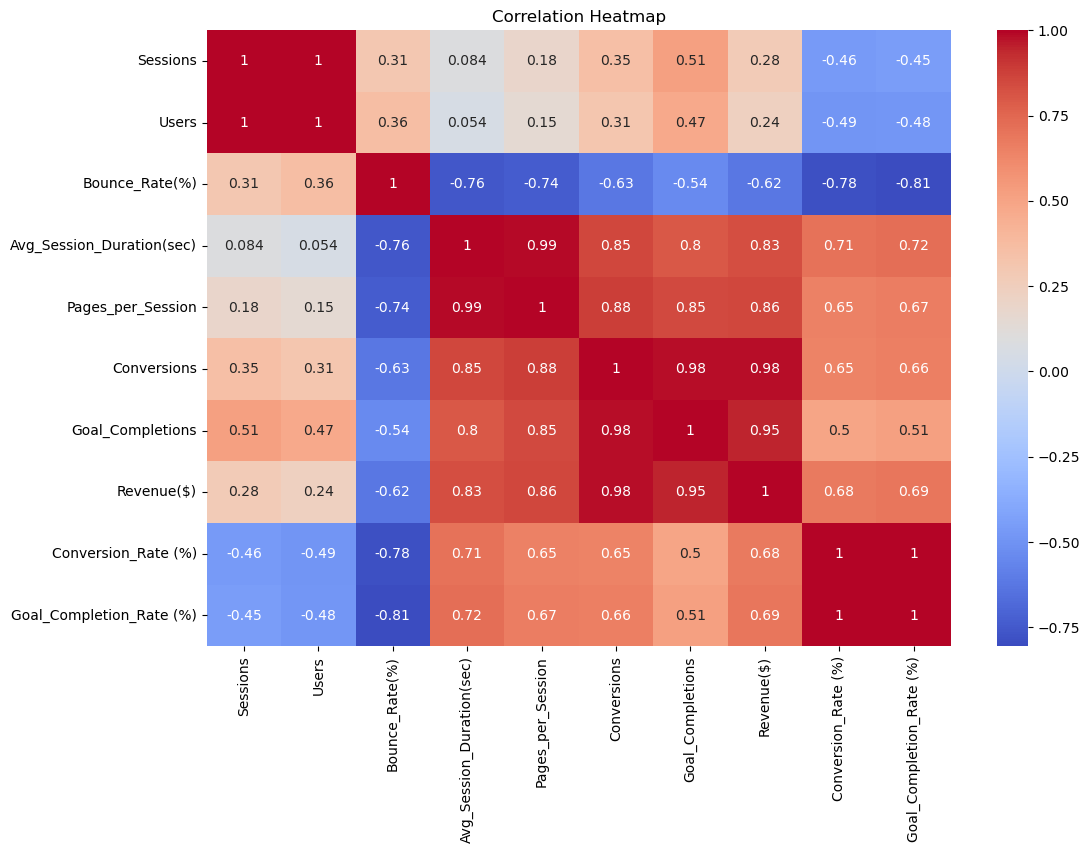

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## 13. Revenue Trend

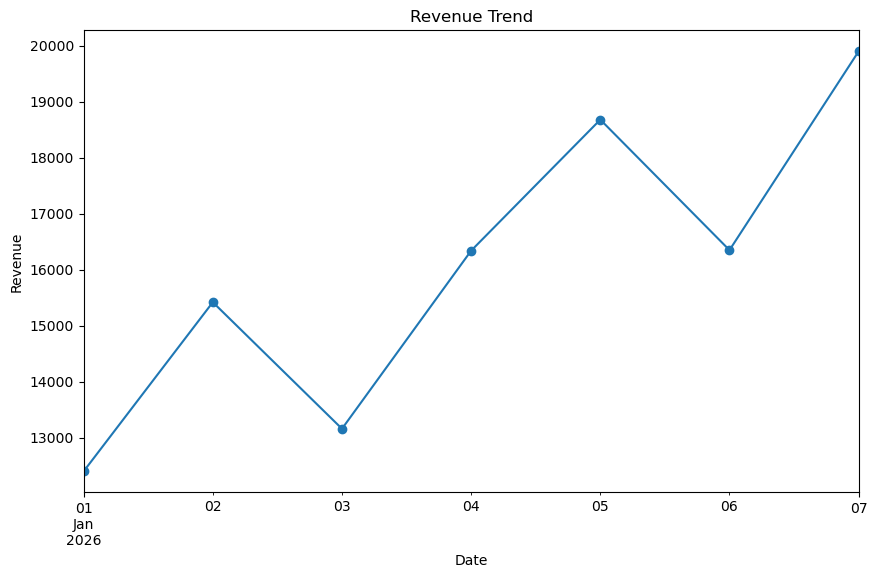

In [29]:
revenue_day = df.groupby("Date")["Revenue($)"].sum()

plt.figure(figsize=(10,6))
revenue_day.plot(marker='o')
plt.title("Revenue Trend")
plt.ylabel("Revenue")
plt.show()

## 14. Traffic Source vs Revenue

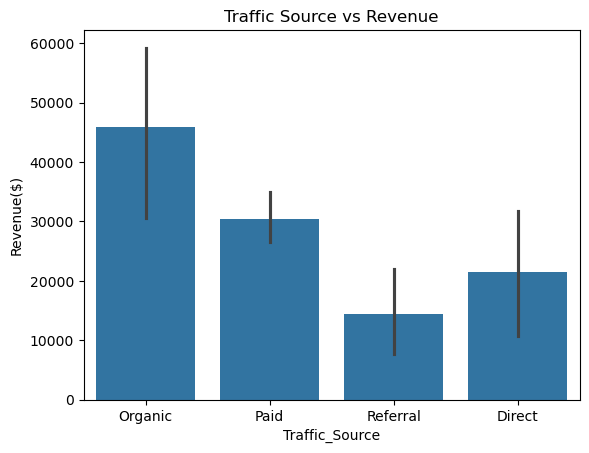

In [30]:
sns.barplot(data=df,
            x="Traffic_Source",
            y="Revenue($)",
            estimator=sum)

plt.title("Traffic Source vs Revenue")
plt.show()

## 15. Bounce Rate Distribution

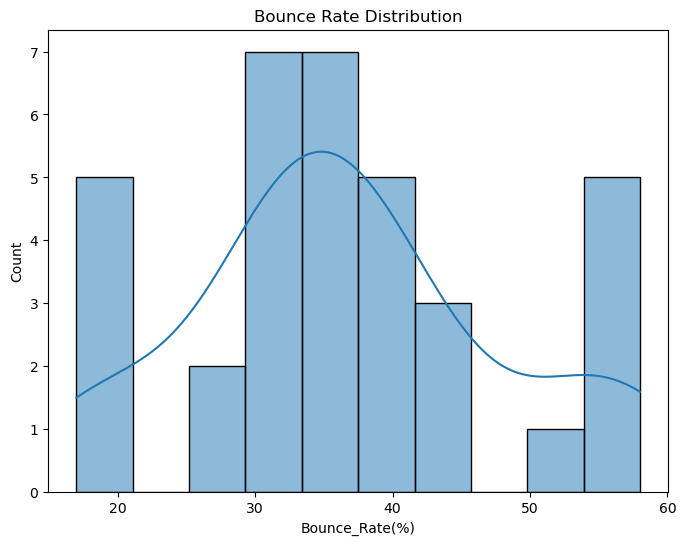

In [31]:
plt.figure(figsize=(8,6))

sns.histplot(df["Bounce_Rate(%)"], bins=10, kde=True)

plt.title("Bounce Rate Distribution")
plt.show()

## 16. Scatter Plot (Sessions vs Revenue)

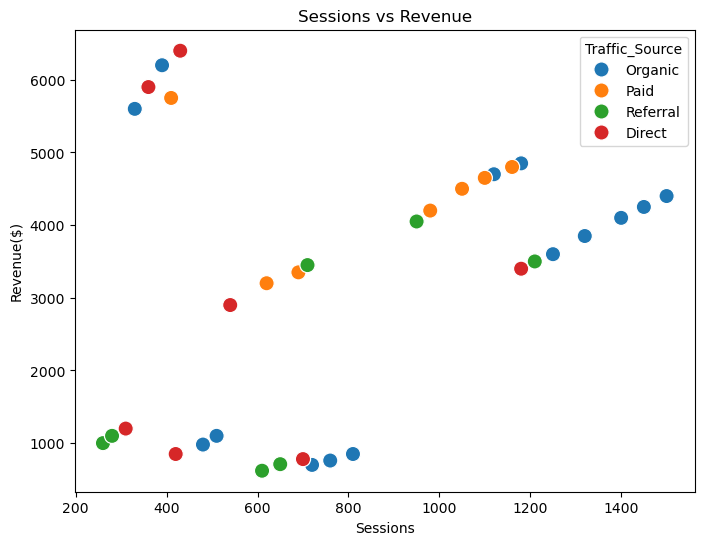

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="Sessions",
                y="Revenue($)",
                hue="Traffic_Source",
                s=120)

plt.title("Sessions vs Revenue")
plt.show()

## 17. Business Summary (KPIs)

In [33]:
print("Total Sessions :", df["Sessions"].sum())

print("Total Users :", df["Users"].sum())

print("Average Bounce Rate :", round(df["Bounce_Rate(%)"].mean(),2), "%")

print("Average Session Duration :", round(df["Avg_Session_Duration(sec)"].mean(),2), "sec")

print("Average Pages/Session :", round(df["Pages_per_Session"].mean(),2))

print("Total Revenue : $", df["Revenue($)"].sum())

print("Total Conversions :", df["Conversions"].sum())

print("Total Goal Completions :", df["Goal_Completions"].sum())

Total Sessions : 27840
Total Users : 23070
Average Bounce Rate : 36.6 %
Average Session Duration : 239.8 sec
Average Pages/Session : 4.38
Total Revenue : $ 112250
Total Conversions : 2043
Total Goal Completions : 2444
